FETAL HEALTH CLASSIFICATION - MACHINE LEARNING PIPELINE

[STEP 1] Loading Dataset...
Dataset Shape: (2126, 22)
Total Records: 2126
Total Features: 21

First 5 rows:
   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.0

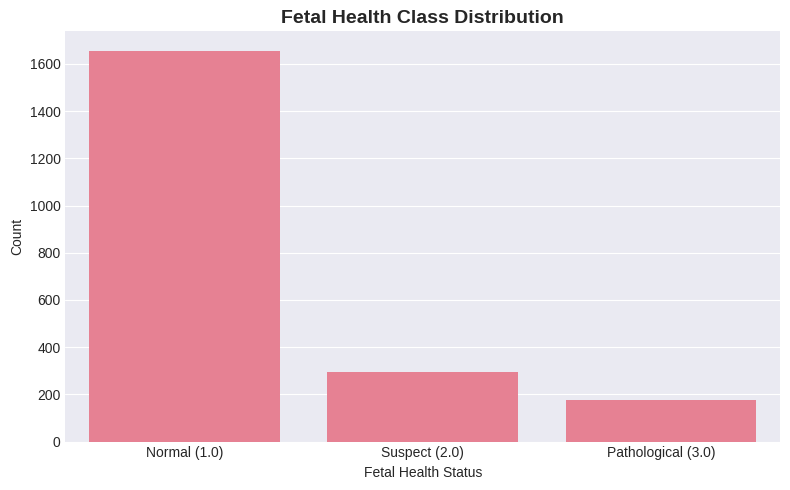


Class Imbalance Ratio:
Class 1.0: 1655 samples (77.85%)
Class 2.0: 295 samples (13.88%)
Class 3.0: 176 samples (8.28%)

[STEP 3] Data Preprocessing

[3.1] Removing Duplicate Records...
Records before: 2126
Records after: 2113
Duplicates removed: 13

[3.2] Correlation Analysis...


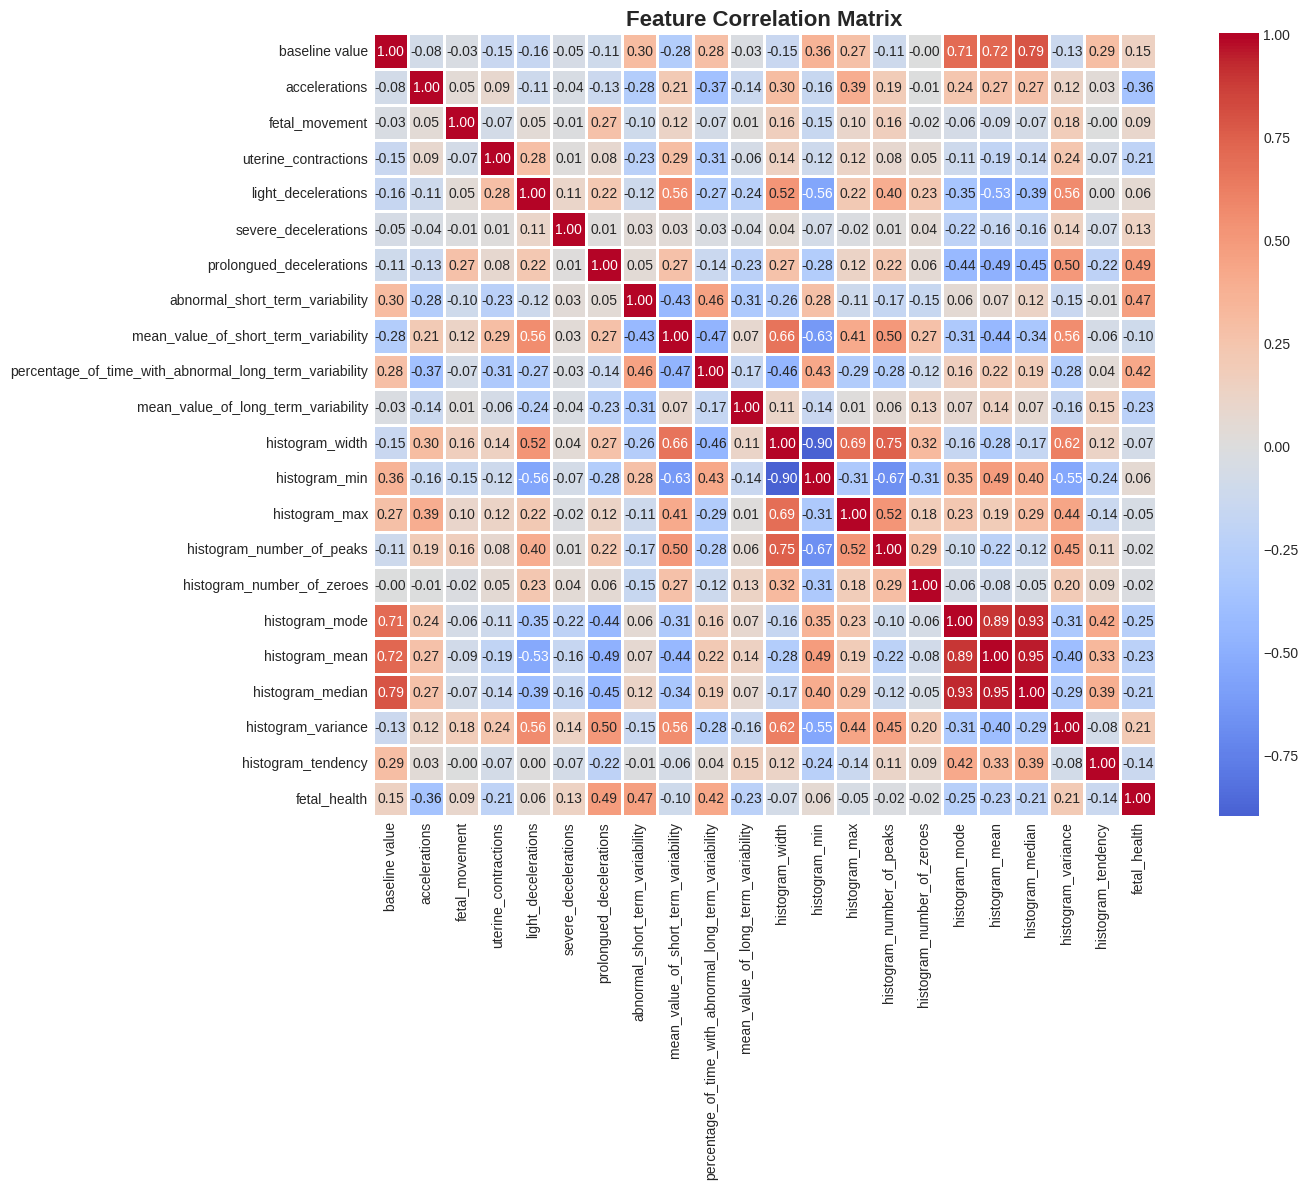


Highly Correlated Features with baseline_value:
baseline value      1.000000
histogram_median    0.788487
histogram_mean      0.722152
histogram_mode      0.708074
Name: baseline value, dtype: float64

Feature Correlation with Target (fetal_health):
fetal_health                                              1.000000
prolongued_decelerations                                  0.486752
abnormal_short_term_variability                           0.469671
percentage_of_time_with_abnormal_long_term_variability    0.421634
histogram_variance                                        0.208171
baseline value                                            0.146077
severe_decelerations                                      0.132408
fetal_movement                                            0.088057
histogram_min                                             0.063529
light_decelerations                                       0.059651
histogram_number_of_zeroes                               -0.016376
histogram_nu

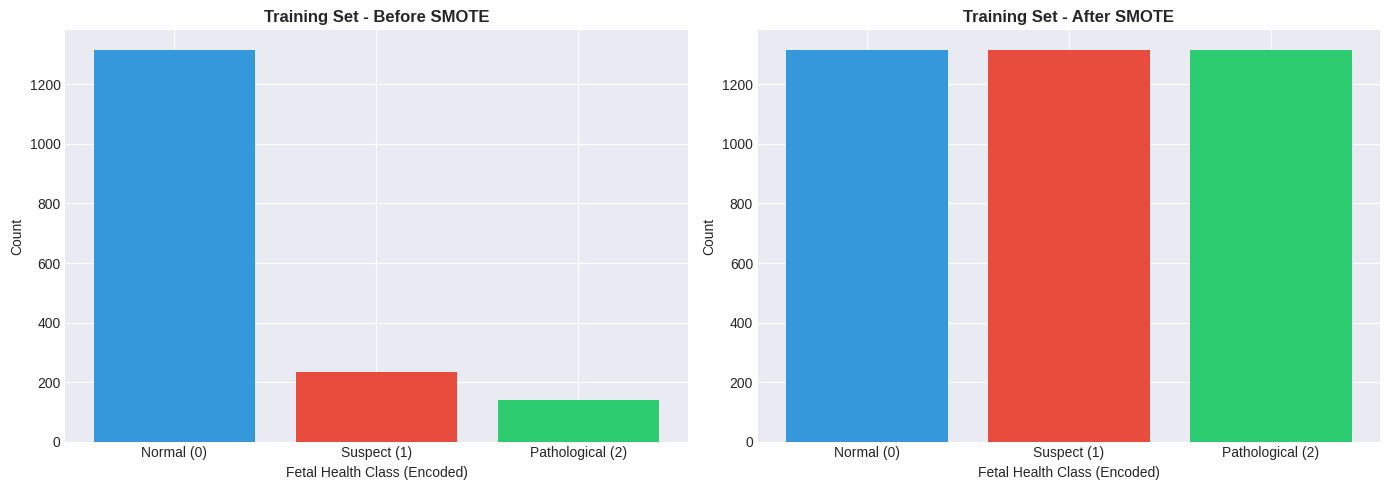


[STEP 4] Model Building and Training

Model Hyperparameters:
--------------------------------------------------------------------------------

Decision Tree:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

XGBoost:
{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_byle

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:37] WARNING: /w

Cross-Validation Scores: [0.97974684 0.97341772 0.96582278 0.97591888 0.97718631]
Mean CV Accuracy: 0.9744 (+/- 0.0048)
Min CV Accuracy: 0.9658
Max CV Accuracy: 0.9797

K-Nearest Neighbors:
----------------------------------------
Cross-Validation Scores: [0.9556962  0.94050633 0.94556962 0.9531052  0.96451204]
Mean CV Accuracy: 0.9519 (+/- 0.0083)
Min CV Accuracy: 0.9405
Max CV Accuracy: 0.9645

Gradient Boosting:
----------------------------------------
Cross-Validation Scores: [0.97341772 0.95316456 0.95696203 0.96831432 0.96070976]
Mean CV Accuracy: 0.9625 (+/- 0.0074)
Min CV Accuracy: 0.9532
Max CV Accuracy: 0.9734


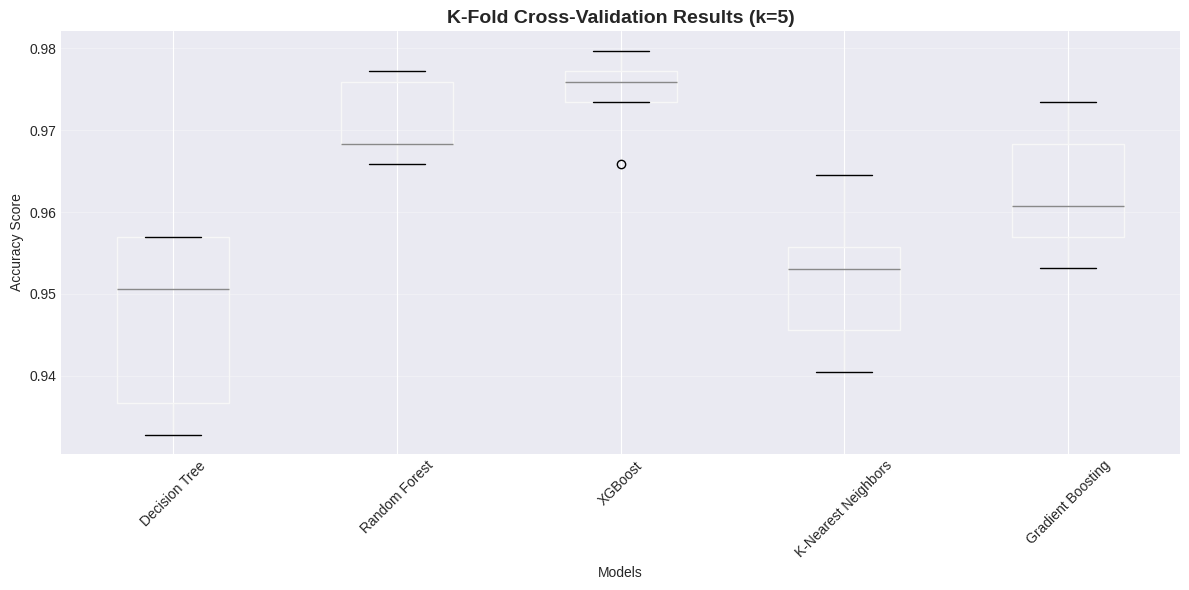


[STEP 6] Training Models on Full Training Set

Training Decision Tree...
✓ Decision Tree trained successfully

Training Random Forest...
✓ Random Forest trained successfully

Training XGBoost...
✓ XGBoost trained successfully

Training K-Nearest Neighbors...
✓ K-Nearest Neighbors trained successfully

Training Gradient Boosting...
✓ Gradient Boosting trained successfully

[STEP 7] Model Performance Comparison

Performance Metrics (Table II from Paper):
              Model Precision Recall F1-Score Accuracy  ROC-AUC
      Decision Tree       92%    92%      92%      92%   0.8901
      Random Forest       94%    94%      94%      94%   0.9839
            XGBoost       94%    94%      94%      94%   0.9865
K-Nearest Neighbors       90%    87%      88%      87%   0.9399
  Gradient Boosting       93%    93%      93%      93%   0.9768


In [11]:
# ============================================================================
# Intelligent Classification of Fetal Health Conditions Using CTG Features
# Following Paper Implementation with K-Fold Cross-Validation - FIXED VERSION
# ============================================================================

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("=" * 80)
print("FETAL HEALTH CLASSIFICATION - MACHINE LEARNING PIPELINE")
print("=" * 80)

# ============================================================================
# 1. DATA LOADING
# ============================================================================
print("\n[STEP 1] Loading Dataset...")
df = pd.read_csv('/kaggle/input/fetal-health-classification/fetal_health.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1] - 1}")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nTarget Variable Distribution:")
print(df['fetal_health'].value_counts())

# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 2] Exploratory Data Analysis")
print("=" * 80)

# Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='fetal_health')
plt.title('Fetal Health Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Fetal Health Status')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Normal (1.0)', 'Suspect (2.0)', 'Pathological (3.0)'])
plt.tight_layout()
plt.savefig('class_distribution_before.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClass Imbalance Ratio:")
class_counts = df['fetal_health'].value_counts()
for cls, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Class {cls}: {count} samples ({percentage:.2f}%)")

# ============================================================================
# 3. DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 3] Data Preprocessing")
print("=" * 80)

# Step 3.1: Remove Duplicates
print("\n[3.1] Removing Duplicate Records...")
df_clean = df.drop_duplicates()
print(f"Records before: {df.shape[0]}")
print(f"Records after: {df_clean.shape[0]}")
print(f"Duplicates removed: {df.shape[0] - df_clean.shape[0]}")

# Step 3.2: Correlation Analysis
print("\n[3.2] Correlation Analysis...")
correlation_matrix = df_clean.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Identify highly correlated features (threshold > 0.7) with baseline_value
print("\nHighly Correlated Features with baseline_value:")
baseline_corr = correlation_matrix['baseline value'].sort_values(ascending=False)
print(baseline_corr[baseline_corr > 0.7])

# Correlation with target
print("\nFeature Correlation with Target (fetal_health):")
target_corr = correlation_matrix['fetal_health'].sort_values(ascending=False)
print(target_corr)

# Step 3.3: Feature Selection - Remove highly correlated histogram features
print("\n[3.3] Feature Selection - Removing Redundant Features...")
features_to_drop = []

# Check histogram features correlation with baseline_value
histogram_features = ['histogram_width', 'histogram_min', 'histogram_max', 
                     'histogram_number_of_peaks', 'histogram_number_of_zeroes',
                     'histogram_mode', 'histogram_mean', 'histogram_median', 
                     'histogram_variance', 'histogram_tendency']

print("\nHistogram Features Correlation with baseline_value:")
for feat in histogram_features:
    corr_val = abs(correlation_matrix.loc['baseline value', feat])
    print(f"{feat}: {corr_val:.4f}")
    if corr_val > 0.7:
        features_to_drop.append(feat)

print(f"\nFeatures to drop (correlation > 0.7): {features_to_drop}")

# Separate features and target
X = df_clean.drop(['fetal_health'] + features_to_drop, axis=1)
y = df_clean['fetal_health']

print(f"\nFeatures after selection: {X.shape[1]}")
print(f"Remaining features: {list(X.columns)}")

# ============================================================================
# FIX: Encode target labels to 0, 1, 2 for XGBoost compatibility
# ============================================================================
print("\n[3.3.5] Encoding Target Labels for Model Compatibility...")
print("Original labels:", y.unique())

# Create label encoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:", np.unique(y_encoded))
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Step 3.4: Z-Score Normalization (Standardization)
print("\n[3.4] Applying Z-Score Normalization...")
print("Formula: Z = (X - μ) / σ")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nNormalized Data Statistics:")
print(X_scaled.describe())

# Verify normalization (mean ≈ 0, std ≈ 1)
print("\nVerification - Mean and Std after normalization:")
print(f"Mean: {X_scaled.mean().mean():.6f}")
print(f"Std: {X_scaled.std().mean():.6f}")

# Step 3.5: Train-Test Split
print("\n[3.5] Splitting Data into Train and Test Sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} ({(X_train.shape[0]/len(X_scaled)*100):.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({(X_test.shape[0]/len(X_scaled)*100):.1f}%)")

print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())

# Step 3.6: Handle Class Imbalance using SMOTE
print("\n[3.6] Handling Class Imbalance using SMOTE...")
print("Before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

# Visualize balanced distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
y_train_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(y_train_counts.index, y_train_counts.values, 
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Training Set - Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fetal Health Class (Encoded)')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Normal (0)', 'Suspect (1)', 'Pathological (2)'])

# After SMOTE
y_train_balanced_counts = pd.Series(y_train_balanced).value_counts().sort_index()
axes[1].bar(y_train_balanced_counts.index, y_train_balanced_counts.values,
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Training Set - After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fetal Health Class (Encoded)')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Normal (0)', 'Suspect (1)', 'Pathological (2)'])

plt.tight_layout()
plt.savefig('class_balance_smote.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 4. MODEL BUILDING
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 4] Model Building and Training")
print("=" * 80)

# Define models with hyperparameters as per paper
models = {
    'Decision Tree': DecisionTreeClassifier(
        criterion='gini',
        splitter='best',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_lambda=1,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        use_label_encoder=False
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski',
        p=2,
        weights='uniform'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=1.0,
        min_samples_split=2,
        min_samples_leaf=1,
        loss='log_loss',
        random_state=42
    )
}

# Display model hyperparameters
print("\nModel Hyperparameters:")
print("-" * 80)
for name, model in models.items():
    print(f"\n{name}:")
    print(model.get_params())

# ============================================================================
# 5. K-FOLD CROSS-VALIDATION
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 5] K-Fold Cross-Validation (k=5)")
print("=" * 80)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    print(f"\n{name}:")
    print("-" * 40)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced, 
                                cv=kfold, scoring='accuracy', n_jobs=-1)
    
    cv_results[name] = cv_scores
    
    print(f"Cross-Validation Scores: {cv_scores}")
    print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Min CV Accuracy: {cv_scores.min():.4f}")
    print(f"Max CV Accuracy: {cv_scores.max():.4f}")

# Visualize CV results
plt.figure(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot()
plt.title('K-Fold Cross-Validation Results (k=5)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_results.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. MODEL TRAINING AND EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 6] Training Models on Full Training Set")
print("=" * 80)

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # ROC-AUC (One-vs-Rest for multiclass)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    
    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }
    
    print(f"✓ {name} trained successfully")

# ============================================================================
# 7. PERFORMANCE COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 7] Model Performance Comparison")
print("=" * 80)

# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

# Format as percentages
results_df_display = results_df.copy()
results_df_display['Precision'] = (results_df_display['Precision'] * 100).round(0).astype(int).astype(str) + '%'
results_df_display['Recall'] = (results_df_display['Recall'] * 100).round(0).astype(int).astype(str) + '%'
results_df_display['F1-Score'] = (results_df_display['F1-Score'] * 100).round(0).astype(int).astype(str) + '%'
results_df_display['Accuracy'] = (results_df_display['Accuracy'] * 100).round(0).astype(int).astype(str) + '%'
results_df_display['ROC-AUC'] = results_df_display['ROC-AUC'].round(4)

print("\nPerformance Metrics (Table II from Paper):")
print("=" * 100)
print(results_df_display.to_string(index=False))
print("=" * 100)





[STEP 8] ROC-AUC Curve Analysis


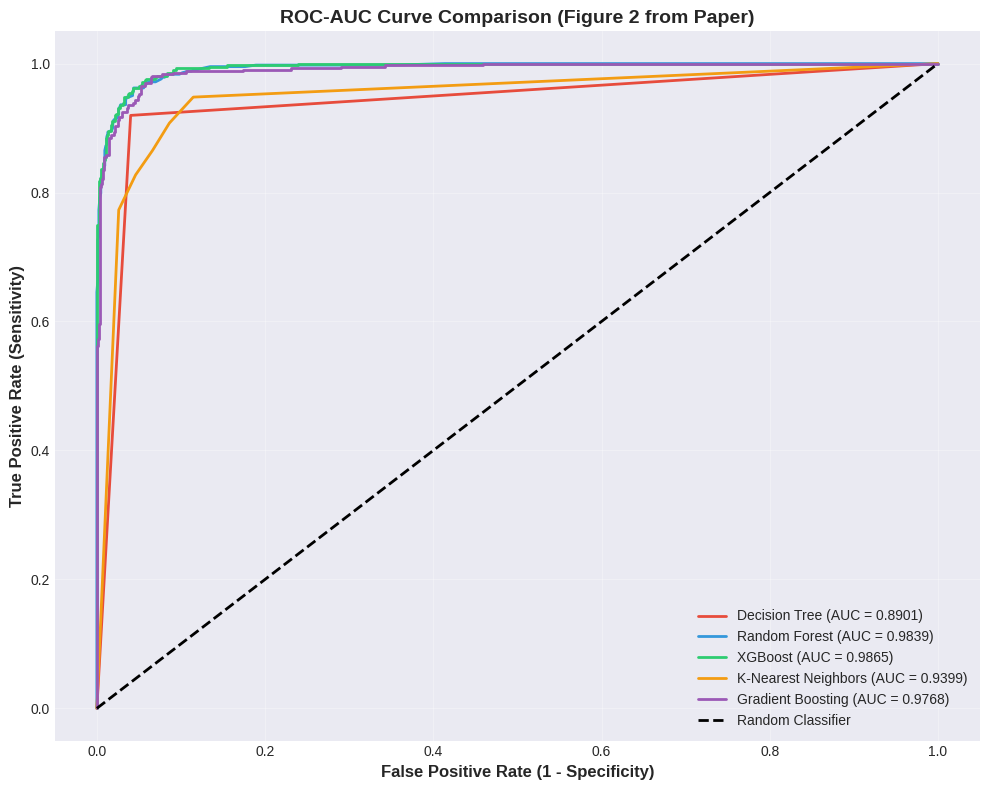

In [12]:

# ============================================================================
# 8. ROC-AUC CURVE ANALYSIS
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] ROC-AUC Curve Analysis")
print("=" * 80)

plt.figure(figsize=(10, 8))

colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for idx, (name, result) in enumerate(results.items()):
    # Calculate ROC curve for each class and average
    y_pred_proba = result['y_pred_proba']
    
    # For multiclass, we'll plot the micro-average ROC curve
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    
    # Compute micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
    roc_auc = result['roc_auc']
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', 
             linewidth=2, color=colors_roc[idx])

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('ROC-AUC Curve Comparison (Figure 2 from Paper)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


# XGboost 

XGBoost MODEL WITH K-FOLD CROSS-VALIDATION

[STEP 1] Initializing XGBoost Model
--------------------------------------------------------------------------------

XGBoost Hyperparameters:
  colsample_bytree: 0.8
  gamma: 0
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 100
  reg_lambda: 1
  subsample: 0.8

[STEP 2] K-Fold Cross-Validation (k=5)
--------------------------------------------------------------------------------

⏳ Running 5-Fold Cross-Validation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [05:42:58] WARNING: /w


✓ Cross-Validation Completed!

--------------------------------------------------------------------------------
ACCURACY - Cross-Validation Results:
--------------------------------------------------------------------------------
  Fold 1: 0.9797
  Fold 2: 0.9734
  Fold 3: 0.9658
  Fold 4: 0.9759
  Fold 5: 0.9772

  Mean Accuracy: 0.9744 (+/- 0.0048)
  Min Accuracy:  0.9658
  Max Accuracy:  0.9797

--------------------------------------------------------------------------------
PRECISION - Cross-Validation Results:
--------------------------------------------------------------------------------
  Mean Precision: 0.9746 (+/- 0.0048)

--------------------------------------------------------------------------------
RECALL - Cross-Validation Results:
--------------------------------------------------------------------------------
  Mean Recall: 0.9744 (+/- 0.0048)

--------------------------------------------------------------------------------
F1-SCORE - Cross-Validation Results:
-------

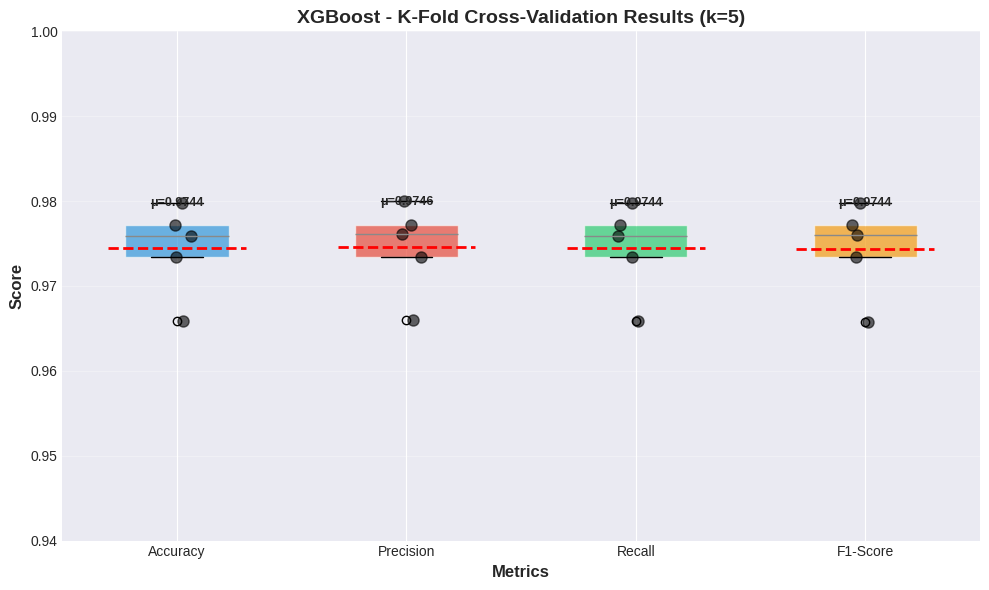

[5.2] Plotting Accuracy Across Folds...


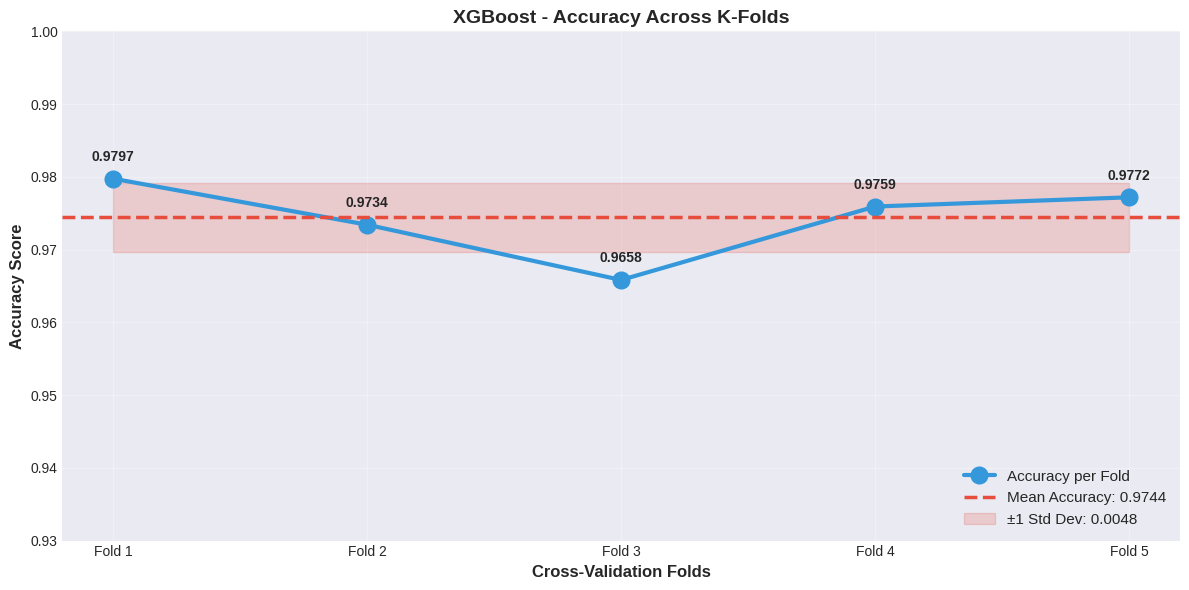

[5.3] Plotting CV vs Test Metrics...


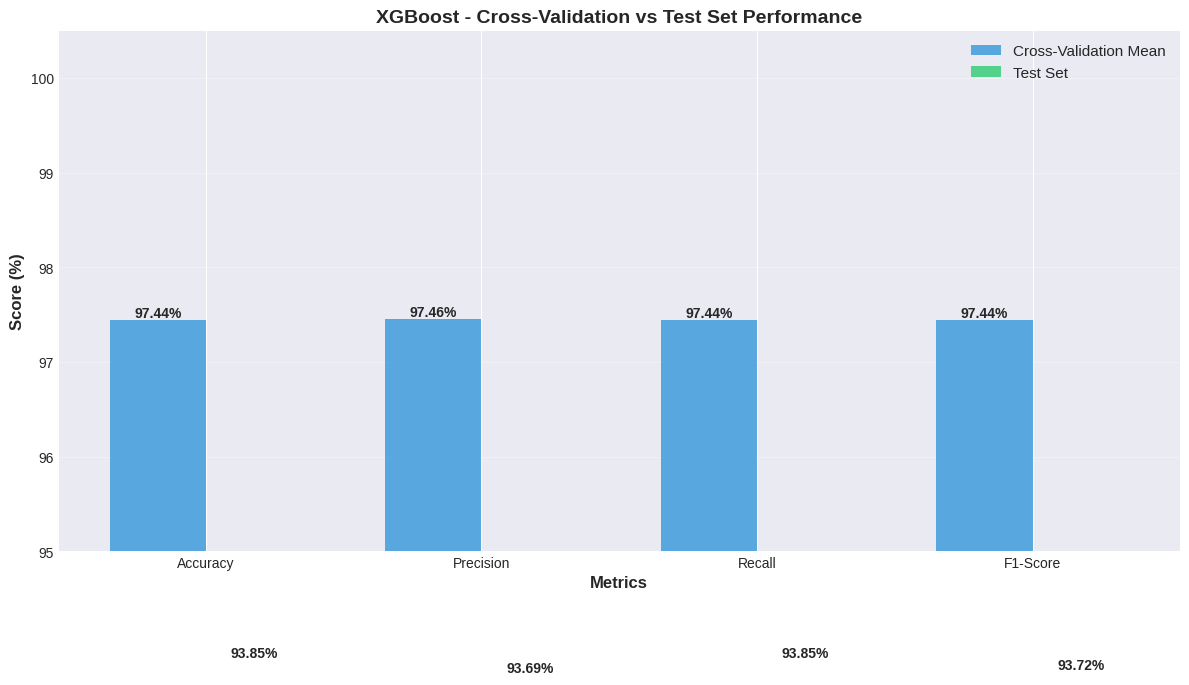

[5.4] Plotting ROC Curves...


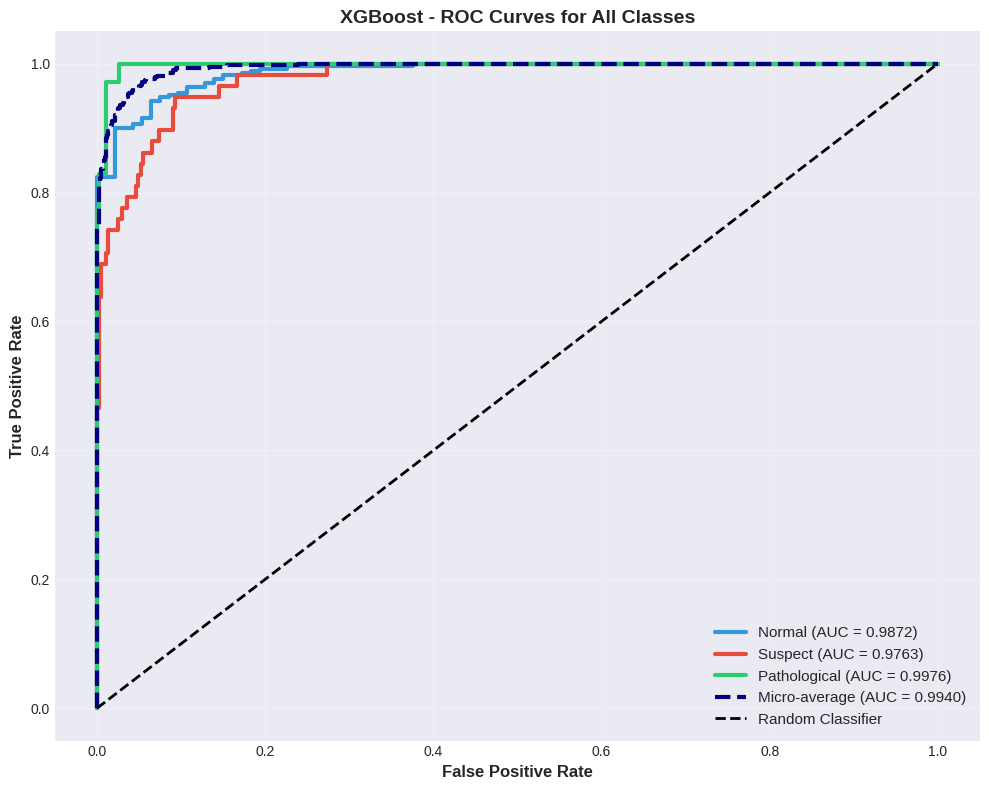

[5.5] Plotting Single ROC Curve...


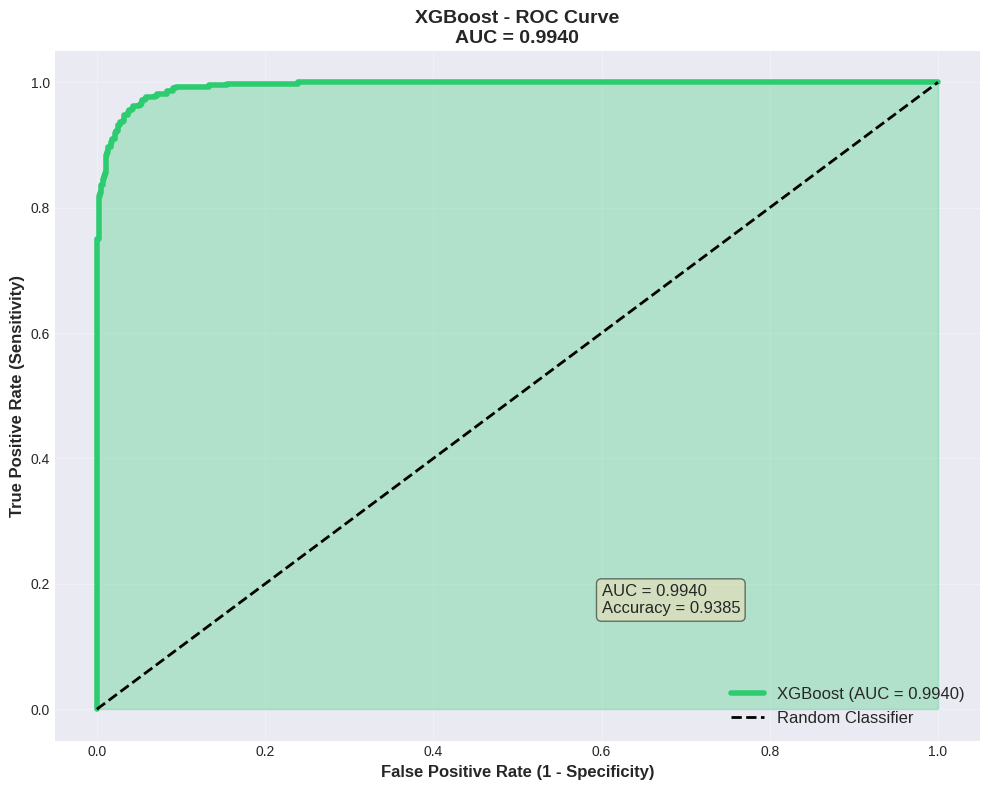

[5.6] Plotting Confusion Matrix...


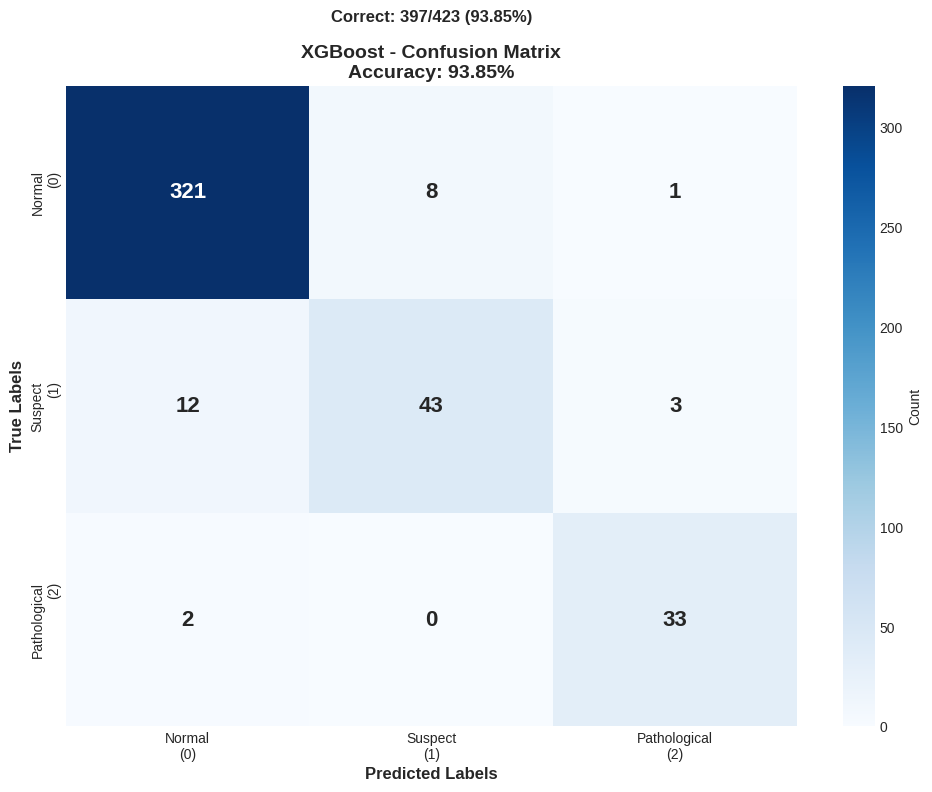

[5.7] Plotting F1-Score...


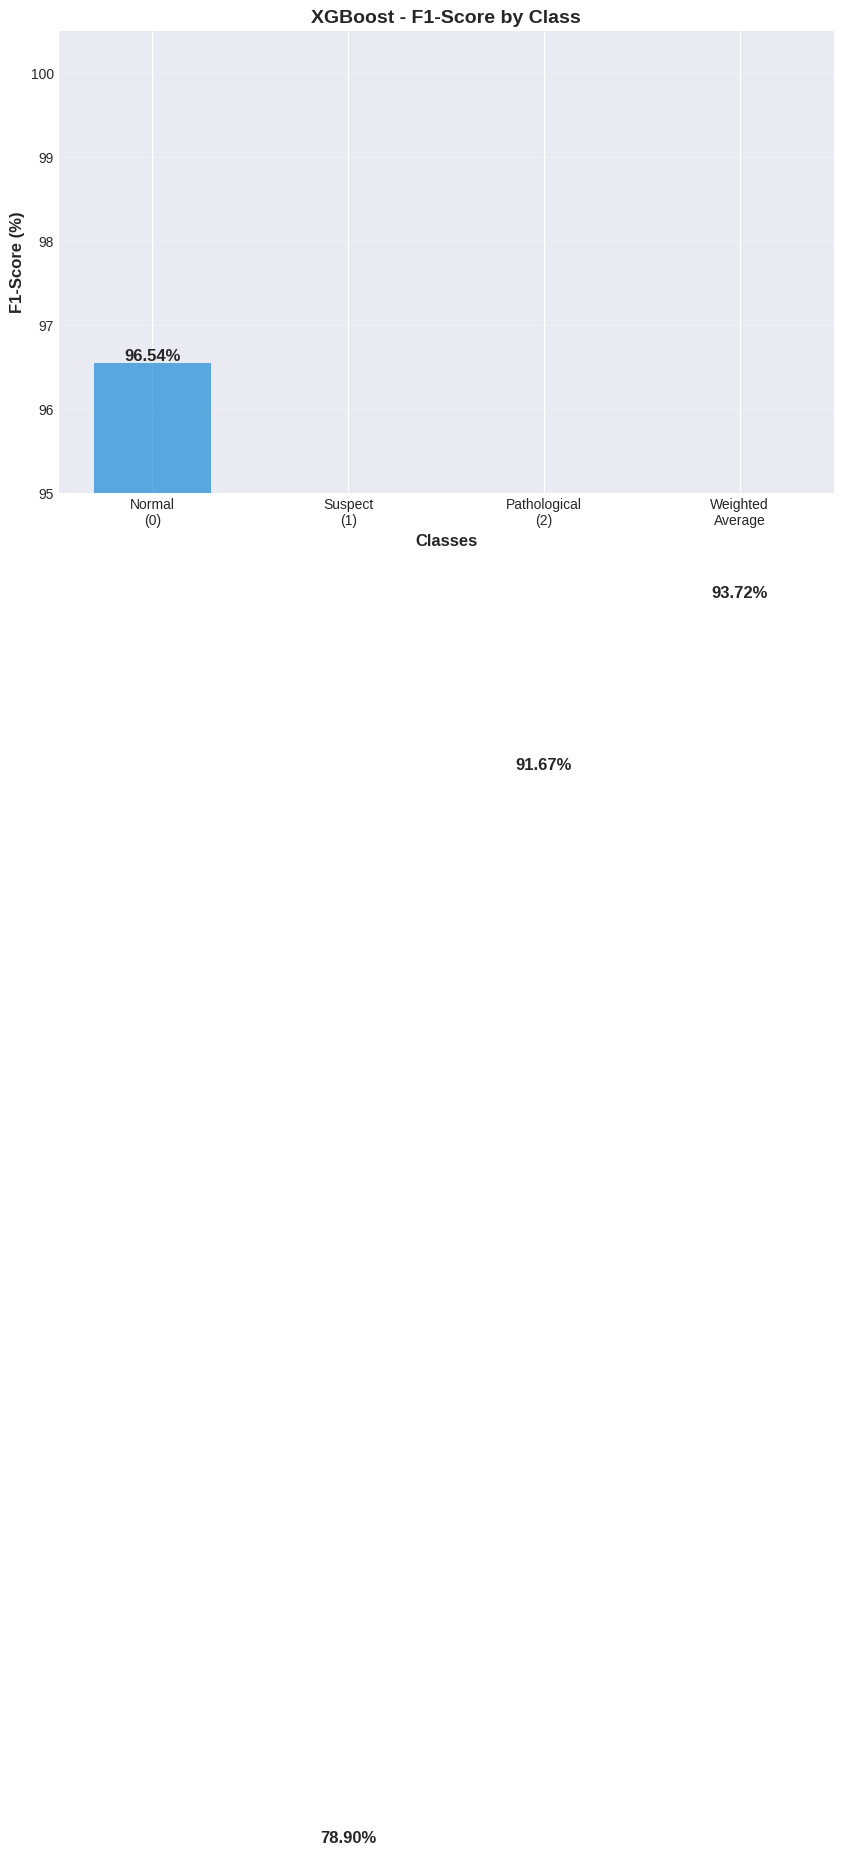

[5.8] Plotting Feature Importance...


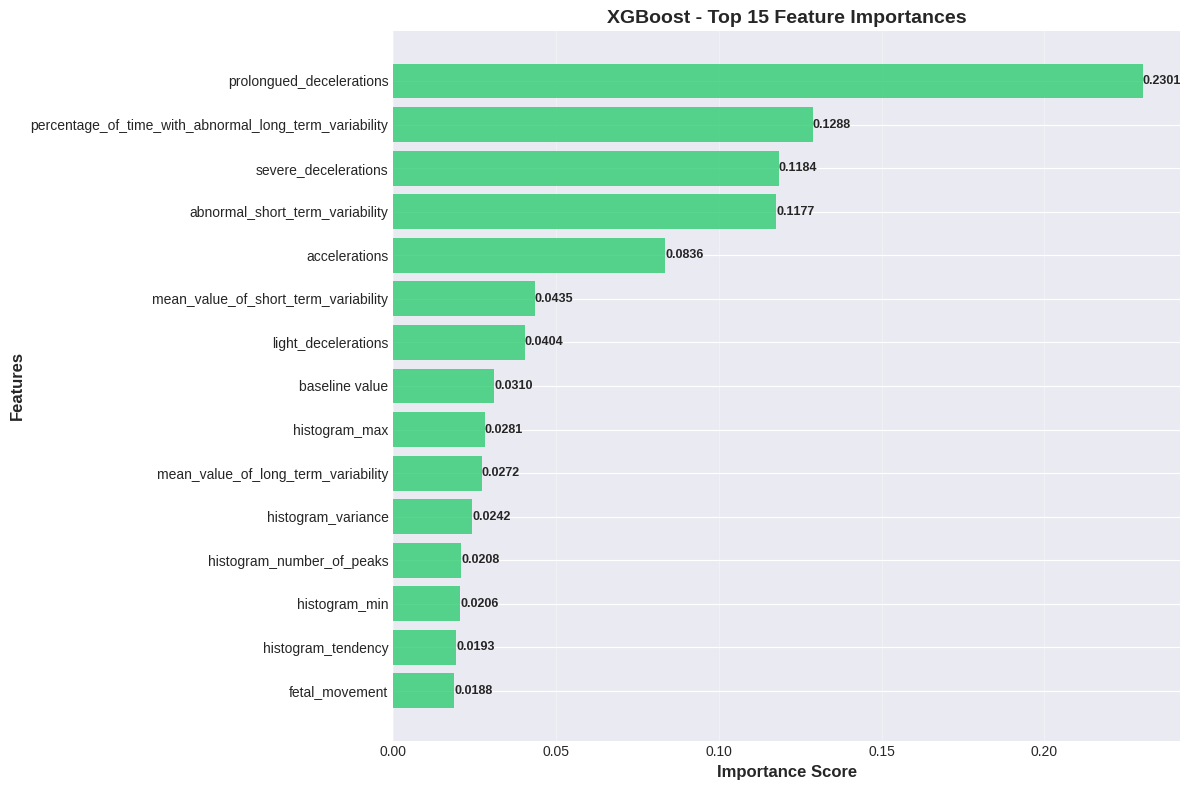


[STEP 6] Detailed Classification Report
--------------------------------------------------------------------------------

XGBoost Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97       330
     Suspect       0.84      0.74      0.79        58
Pathological       0.89      0.94      0.92        35

    accuracy                           0.94       423
   macro avg       0.90      0.89      0.89       423
weighted avg       0.94      0.94      0.94       423


[STEP 7] Performance Summary


   Metric   CV Mean    CV Std  Test Score
 Accuracy  0.974419  0.004758    0.938534
Precision  0.974551  0.004774    0.936944
   Recall  0.974419  0.004758    0.938534
 F1-Score   0.97441  0.004801    0.937190
  ROC-AUC         -         -    0.986538


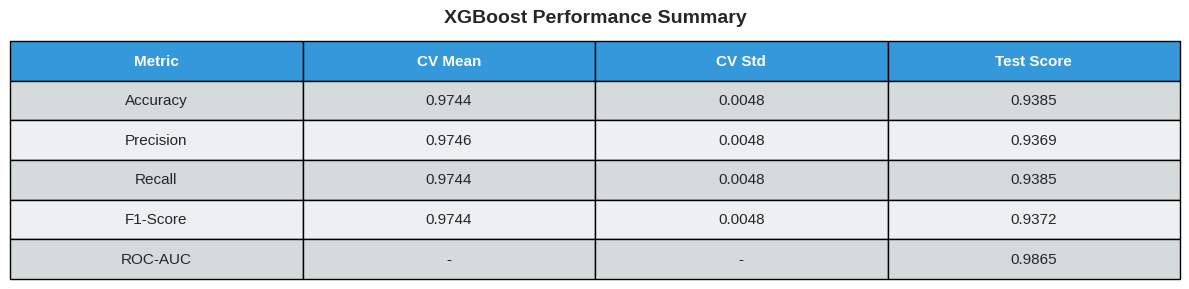


[STEP 8] Saving Model
--------------------------------------------------------------------------------
✓ XGBoost model saved: xgboost_model.pkl

XGBOOST K-FOLD CROSS-VALIDATION COMPLETED!

📊 FINAL RESULTS:

✓ Cross-Validation (5-Fold):
  - Mean Accuracy:  0.9744 ± 0.0048
  - Mean Precision: 0.9746 ± 0.0048
  - Mean Recall:    0.9744 ± 0.0048
  - Mean F1-Score:  0.9744 ± 0.0048

✓ Test Set Performance:
  - Accuracy:  0.9385 (93.85%)
  - Precision: 0.9369 (93.69%)
  - Recall:    0.9385 (93.85%)
  - F1-Score:  0.9372 (93.72%)
  - ROC-AUC:   0.9865

📁 Files Generated:
  1. xgboost_model.pkl
  2. xgboost_kfold_boxplot.png
  3. xgboost_accuracy_folds.png
  4. xgboost_cv_vs_test.png
  5. xgboost_roc_curves.png
  6. xgboost_roc_single.png
  7. xgboost_confusion_matrix.png
  8. xgboost_f1_score.png
  9. xgboost_feature_importance.png
  10. xgboost_summary_table.png



In [13]:
# ============================================================================
# XGBoost Model with K-Fold Cross-Validation (No Hyperparameter Tuning)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, make_scorer)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("XGBoost MODEL WITH K-FOLD CROSS-VALIDATION")
print("=" * 80)

# ============================================================================
# 1. INITIALIZE XGBoost MODEL
# ============================================================================
print("\n[STEP 1] Initializing XGBoost Model")
print("-" * 80)

# XGBoost with parameters from the paper
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

print("\nXGBoost Hyperparameters:")
for param, value in xgb_model.get_params().items():
    if param in ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 
                 'colsample_bytree', 'gamma', 'reg_lambda']:
        print(f"  {param}: {value}")

# ============================================================================
# 2. K-FOLD CROSS-VALIDATION WITH MULTIPLE METRICS
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 2] K-Fold Cross-Validation (k=5)")
print("-" * 80)

# Initialize K-Fold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted'),
    'f1': make_scorer(f1_score, average='weighted')
}

# Perform cross-validation with multiple metrics
print("\n⏳ Running 5-Fold Cross-Validation...")
cv_results = cross_validate(
    xgb_model, 
    X_train_balanced, 
    y_train_balanced,
    cv=kfold,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

# Extract results
cv_accuracy = cv_results['test_accuracy']
cv_precision = cv_results['test_precision']
cv_recall = cv_results['test_recall']
cv_f1 = cv_results['test_f1']

print("\n✓ Cross-Validation Completed!")

print("\n" + "-" * 80)
print("ACCURACY - Cross-Validation Results:")
print("-" * 80)
print(f"  Fold 1: {cv_accuracy[0]:.4f}")
print(f"  Fold 2: {cv_accuracy[1]:.4f}")
print(f"  Fold 3: {cv_accuracy[2]:.4f}")
print(f"  Fold 4: {cv_accuracy[3]:.4f}")
print(f"  Fold 5: {cv_accuracy[4]:.4f}")
print(f"\n  Mean Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"  Min Accuracy:  {cv_accuracy.min():.4f}")
print(f"  Max Accuracy:  {cv_accuracy.max():.4f}")

print("\n" + "-" * 80)
print("PRECISION - Cross-Validation Results:")
print("-" * 80)
print(f"  Mean Precision: {cv_precision.mean():.4f} (+/- {cv_precision.std():.4f})")

print("\n" + "-" * 80)
print("RECALL - Cross-Validation Results:")
print("-" * 80)
print(f"  Mean Recall: {cv_recall.mean():.4f} (+/- {cv_recall.std():.4f})")

print("\n" + "-" * 80)
print("F1-SCORE - Cross-Validation Results:")
print("-" * 80)
print(f"  Mean F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# ============================================================================
# 3. TRAIN MODEL ON FULL TRAINING DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 3] Training XGBoost on Full Training Data")
print("-" * 80)

print("\n⏳ Training model...")
xgb_model.fit(X_train_balanced, y_train_balanced)
print("✓ Training completed!")

# ============================================================================
# 4. EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 4] Evaluating on Test Set")
print("-" * 80)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')
test_roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print("\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

# ============================================================================
# 5. VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 5] Creating Visualizations")
print("-" * 80)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 5.1 K-Fold Cross-Validation Results (Box Plot)
# ============================================================================
print("\n[5.1] Plotting K-Fold Cross-Validation Box Plot...")

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data
cv_data = pd.DataFrame({
    'Accuracy': cv_accuracy,
    'Precision': cv_precision,
    'Recall': cv_recall,
    'F1-Score': cv_f1
})

# Create box plot
bp = cv_data.boxplot(ax=ax, patch_artist=True, return_type='dict')

# Customize colors
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points
for i, col in enumerate(cv_data.columns):
    y = cv_data[col]
    x = np.random.normal(i+1, 0.04, size=len(y))
    ax.plot(x, y, 'o', alpha=0.6, color='black', markersize=8)

# Add mean lines
means = cv_data.mean()
for i, (metric, mean) in enumerate(means.items()):
    ax.plot([i+0.7, i+1.3], [mean, mean], 'r--', linewidth=2)
    ax.text(i+1, mean+0.005, f'μ={mean:.4f}', ha='center', fontweight='bold', fontsize=9)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - K-Fold Cross-Validation Results (k=5)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.94, 1.0)

plt.tight_layout()
plt.savefig('xgboost_kfold_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.2 Accuracy Across Folds
# ============================================================================
print("[5.2] Plotting Accuracy Across Folds...")

fig, ax = plt.subplots(figsize=(12, 6))

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
x_pos = np.arange(len(folds))

# Plot line with markers
ax.plot(x_pos, cv_accuracy, marker='o', linewidth=3, markersize=12, 
        color='#3498db', label='Accuracy per Fold')

# Add mean line
mean_acc = cv_accuracy.mean()
ax.axhline(y=mean_acc, color='#e74c3c', linestyle='--', linewidth=2.5,
           label=f'Mean Accuracy: {mean_acc:.4f}')

# Add std deviation band
std_acc = cv_accuracy.std()
ax.fill_between(x_pos, mean_acc - std_acc, mean_acc + std_acc, 
                alpha=0.2, color='#e74c3c', label=f'±1 Std Dev: {std_acc:.4f}')

# Add value labels on points
for i, v in enumerate(cv_accuracy):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

ax.set_xlabel('Cross-Validation Folds', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - Accuracy Across K-Folds', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(0.93, 1.0)

plt.tight_layout()
plt.savefig('xgboost_accuracy_folds.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.3 All Metrics Comparison (CV vs Test)
# ============================================================================
print("[5.3] Plotting CV vs Test Metrics...")

fig, ax = plt.subplots(figsize=(12, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cv_means = [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), cv_f1.mean()]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, [s*100 for s in cv_means], width, 
               label='Cross-Validation Mean', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, [s*100 for s in test_scores], width, 
               label='Test Set', color='#2ecc71', alpha=0.8)

# Add value labels
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - Cross-Validation vs Test Set Performance', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(95, 100.5)

plt.tight_layout()
plt.savefig('xgboost_cv_vs_test.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.4 ROC Curves for All Classes
# ============================================================================
print("[5.4] Plotting ROC Curves...")

# Binarize the output
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Compute ROC curve and AUC for each class
fig, ax = plt.subplots(figsize=(10, 8))

class_names = ['Normal', 'Suspect', 'Pathological']
colors = ['#3498db', '#e74c3c', '#2ecc71']

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
    ax.plot(fpr[i], tpr[i], color=colors[i], linewidth=3,
            label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

# Compute micro-average ROC curve
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', linewidth=3, linestyle='--',
        label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Plot random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - ROC Curves for All Classes', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.5 Single ROC Curve (Micro-Average)
# ============================================================================
print("[5.5] Plotting Single ROC Curve...")

fig, ax = plt.subplots(figsize=(10, 8))

# Plot micro-average ROC curve
ax.plot(fpr_micro, tpr_micro, color='#2ecc71', linewidth=4,
        label=f'XGBoost (AUC = {roc_auc_micro:.4f})')

# Plot random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')

# Fill area under curve
ax.fill_between(fpr_micro, tpr_micro, alpha=0.3, color='#2ecc71')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title(f'XGBoost - ROC Curve\nAUC = {roc_auc_micro:.4f}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(alpha=0.3)

# Add text box with AUC
textstr = f'AUC = {roc_auc_micro:.4f}\nAccuracy = {test_accuracy:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.6, 0.2, textstr, fontsize=12, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('xgboost_roc_single.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.6 Confusion Matrix
# ============================================================================
print("[5.6] Plotting Confusion Matrix...")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

class_labels = ['Normal\n(0)', 'Suspect\n(1)', 'Pathological\n(2)']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicted Labels', fontsize=12, fontweight='bold')
ax.set_ylabel('True Labels', fontsize=12, fontweight='bold')
ax.set_title(f'XGBoost - Confusion Matrix\nAccuracy: {test_accuracy*100:.2f}%', 
             fontsize=14, fontweight='bold')

# Add accuracy text
total = np.sum(cm)
correct = np.trace(cm)
accuracy_text = f'Correct: {correct}/{total} ({test_accuracy*100:.2f}%)'
ax.text(1.5, -0.3, accuracy_text, ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.7 F1-Score Visualization
# ============================================================================
print("[5.7] Plotting F1-Score...")

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate F1-score for each class
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_test, y_pred, average=None)
f1_weighted = f1_score(y_test, y_pred, average='weighted')

classes = ['Normal\n(0)', 'Suspect\n(1)', 'Pathological\n(2)', 'Weighted\nAverage']
f1_scores = list(f1_per_class) + [f1_weighted]
colors_f1 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(classes, [f*100 for f in f1_scores], color=colors_f1, alpha=0.8, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - F1-Score by Class', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(95, 100.5)

plt.tight_layout()
plt.savefig('xgboost_f1_score.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5.8 Feature Importance
# ============================================================================
print("[5.8] Plotting Feature Importance...")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_features = feature_importance.head(15)

bars = ax.barh(range(len(top_features)), top_features['Importance'], 
               color='#2ecc71', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - Top 15 Feature Importances', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.4f}', ha='left', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. DETAILED CLASSIFICATION REPORT
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 6] Detailed Classification Report")
print("-" * 80)

class_names = ['Normal', 'Suspect', 'Pathological']

print("\nXGBoost Classification Report:")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=class_names))

# ============================================================================
# 7. SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 7] Performance Summary")
print("=" * 80)

summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'CV Mean': [cv_accuracy.mean(), cv_precision.mean(), cv_recall.mean(), 
                cv_f1.mean(), '-'],
    'CV Std': [cv_accuracy.std(), cv_precision.std(), cv_recall.std(), 
               cv_f1.std(), '-'],
    'Test Score': [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]
})

print("\n")
print(summary_df.to_string(index=False))

# Create summary visualization
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

table_data = []
for _, row in summary_df.iterrows():
    cv_mean = f"{float(row['CV Mean']):.4f}" if row['CV Mean'] != '-' else '-'
    cv_std = f"{float(row['CV Std']):.4f}" if row['CV Std'] != '-' else '-'
    test_score = f"{row['Test Score']:.4f}"
    table_data.append([row['Metric'], cv_mean, cv_std, test_score])

table = ax.table(cellText=table_data,
                colLabels=['Metric', 'CV Mean', 'CV Std', 'Test Score'],
                cellLoc='center',
                loc='center',
                colColours=['#3498db']*4)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style rows
colors_table = ['#ecf0f1', '#d5dbdb']
for i in range(1, 6):
    for j in range(4):
        table[(i, j)].set_facecolor(colors_table[i % 2])

plt.title('XGBoost Performance Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('xgboost_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. SAVE MODEL
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 8] Saving Model")
print("-" * 80)

import joblib

joblib.dump(xgb_model, 'xgboost_model.pkl')
print("✓ XGBoost model saved: xgboost_model.pkl")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("XGBOOST K-FOLD CROSS-VALIDATION COMPLETED!")
print("=" * 80)

print(f"""
📊 FINAL RESULTS:

✓ Cross-Validation (5-Fold):
  - Mean Accuracy:  {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}
  - Mean Precision: {cv_precision.mean():.4f} ± {cv_precision.std():.4f}
  - Mean Recall:    {cv_recall.mean():.4f} ± {cv_recall.std():.4f}
  - Mean F1-Score:  {cv_f1.mean():.4f} ± {cv_f1.std():.4f}

✓ Test Set Performance:
  - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  - Precision: {test_precision:.4f} ({test_precision*100:.2f}%)
  - Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)
  - F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)
  - ROC-AUC:   {test_roc_auc:.4f}

📁 Files Generated:
  1. xgboost_model.pkl
  2. xgboost_kfold_boxplot.png
  3. xgboost_accuracy_folds.png
  4. xgboost_cv_vs_test.png
  5. xgboost_roc_curves.png
  6. xgboost_roc_single.png
  7. xgboost_confusion_matrix.png
  8. xgboost_f1_score.png
  9. xgboost_feature_importance.png
  10. xgboost_summary_table.png
""")

print("=" * 80)